In [1]:
week = 11
function = 3

In [74]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

In [81]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

In [82]:
print(f"Requested function {function} in week {week}")

print("\nData Loading")

# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)

# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)
# print(f"\tloaded original data set...")

# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)

# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"\tresults will be saved to {results_dir}...")

print("\nData Preprocessing")
print("\tsetting values below numerical precision to zero")
df.loc[df["Y1"].abs() < 1e-6, "Y1"] = 0

print("\tscaling output variable")
scaler = StandardScaler()
df["YScaled"] = scaler.fit_transform(df[["Y1"]])

print("\textracting input variables")
input_cols = data_loading.get_X_cols(df)

print("\tfinding points within threshold of current max")
df_fitting = data_augmentation.extract_distance_from_max(df, "YScaled", input_cols, 12)

print("\tseparating iputs and outputs for fitting")
X = df_fitting[input_cols].to_numpy(dtype=np.float32)
y = df_fitting["YScaled"].to_numpy(dtype=np.float32).reshape(-1,1)


Requested function 3 in week 11

Data Loading
	Loaded initial data: function_3
	Available update files:
		1: new_data_point_wk1.csv
		2: new_data_point_wk10.csv
		3: new_data_point_wk2.csv
		4: new_data_point_wk3.csv
		5: new_data_point_wk4.csv
		6: new_data_point_wk5.csv
		7: new_data_point_wk6.csv
		8: new_data_point_wk7.csv
		9: new_data_point_wk8.csv
		10: new_data_point_wk9.csv
	Added 10 new data points.
	results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_11\function_3...

Data Preprocessing
	setting values below numerical precision to zero
	scaling output variable
	extracting input variables
	finding points within threshold of current max
	separating iputs and outputs for fitting


In [83]:

# =====================================================
# Convert data
# =====================================================

x_train = tf.convert_to_tensor(X, dtype=tf.float32)
y_train = tf.convert_to_tensor(y, dtype=tf.float32)

n_features = X.shape[1]
n_hidden = 4

# =====================================================
# Initialize weights (He initialization)
# =====================================================

W1 = tf.Variable(tf.random.normal(shape=(n_features + 1, n_hidden),stddev=np.sqrt(2 / n_features)))
W2 = tf.Variable(tf.random.normal(shape=(n_hidden, 1),stddev=np.sqrt(2 / n_hidden)))

# =====================================================
# Forward pass
# =====================================================

def forward_pass(x):

    # Add bias column
    bias = tf.ones((tf.shape(x)[0], 1))
    x = tf.concat([x, bias], axis=1)

    hidden = tf.matmul(x, W1)
    hidden = tf.nn.relu(hidden)

    output = tf.matmul(hidden, W2)

    return output

# =====================================================
# Loss / Optimizer
# =====================================================

loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.05)

# =====================================================
# Training step
# =====================================================

@tf.function
def train_step(x, y):

    with tf.GradientTape() as tape:

        y_pred = forward_pass(x)
        loss = loss_fn(y, y_pred)

    gradients = tape.gradient(loss,[W1, W2])

    optimizer.apply_gradients(zip(gradients, [W1, W2]))

    return loss

Epoch 0: Loss = 2.014936
Epoch 250: Loss = 0.325925
Epoch 500: Loss = 0.308978
Epoch 750: Loss = 0.300128
Epoch 1000: Loss = 0.290979
Epoch 1250: Loss = 0.279365
Epoch 1500: Loss = 0.264024
Epoch 1750: Loss = 0.243756
Epoch 2000: Loss = 0.217770
Epoch 2250: Loss = 0.186281
Epoch 2500: Loss = 0.150992
Epoch 2750: Loss = 0.135105
Epoch 3000: Loss = 0.119055
Epoch 3250: Loss = 0.101633
Epoch 3500: Loss = 0.113314
Epoch 3750: Loss = 0.149235
Epoch 4000: Loss = 0.142393
Epoch 4250: Loss = 0.128339
Epoch 4500: Loss = 0.126066
Epoch 4750: Loss = 0.120393
Epoch 5000: Loss = 0.109508
Epoch 5250: Loss = 0.103407
Epoch 5500: Loss = 0.095065
Epoch 5750: Loss = 0.092852
Epoch 6000: Loss = 0.084013
Epoch 6250: Loss = 0.077883
Epoch 6500: Loss = 0.073752
Epoch 6750: Loss = 0.072724
Epoch 7000: Loss = 0.063056
Epoch 7250: Loss = 0.061004
Epoch 7500: Loss = 0.045860
Epoch 7750: Loss = 0.028133
Epoch 8000: Loss = 0.015111
Epoch 8250: Loss = 0.010834
Epoch 8500: Loss = 0.011748
Epoch 8750: Loss = 0.10901

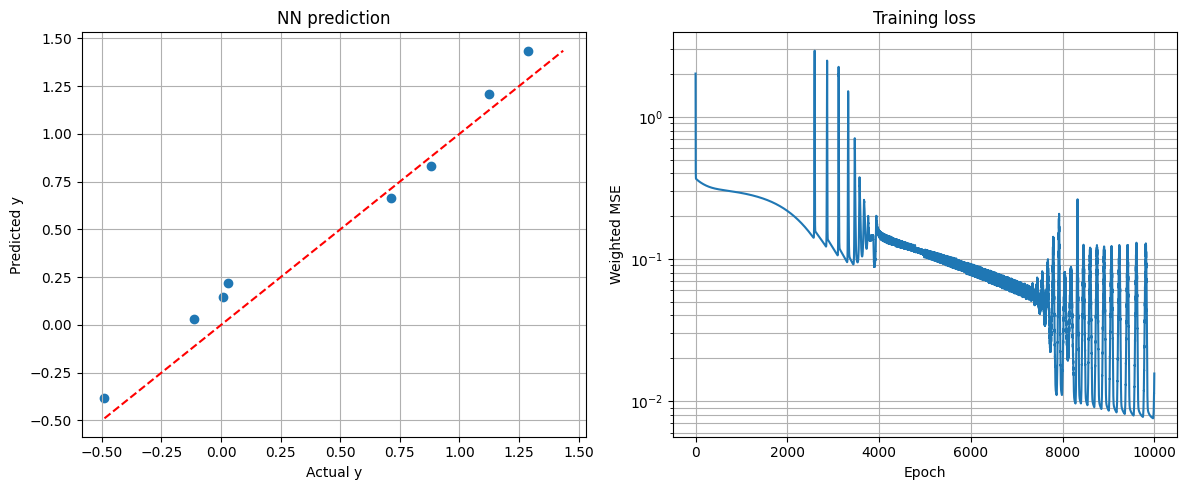

In [84]:
epochs = 10000
loss_history = []

for epoch in range(epochs):

    loss = train_step(x_train, y_train)

    loss_history.append(loss.numpy())

    if epoch % 250 == 0:
        print(f"Epoch {epoch}: Loss = {loss.numpy():.6f}")

y_pred = forward_pass(X).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(12, 5))

ax1.scatter(y.flatten(),y_pred.flatten())

lims = [min(y.min(), y_pred.min()),max(y.max(), y_pred.max())]

ax1.plot(lims,lims,"r--")

ax1.set_xlabel("Actual y")
ax1.set_ylabel("Predicted y")
ax1.set_title("NN prediction")
ax1.grid(True)

# ---------------------
# Loss curve (log scale)
# ---------------------

ax2.plot(loss_history)

ax2.set_yscale("log")      # logarithmic y-axis

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Weighted MSE")
ax2.set_title("Training loss")
ax2.grid(True, which="both")

plt.tight_layout()
plt.show()

In [86]:
print(f"Calaculating Convex Hull around chosen data set...")
hull, points_hull = data_augmentation.compute_convex_hull( df_fitting[input_cols])
internal_points = data_augmentation.seed_convex_hull(points_hull, hull)

y_test = forward_pass(internal_points).numpy()
best_index = np.argmax(y_test)

x_max = internal_points[best_index]
y_max = y_test[best_index]

print("Maximum location:")
print(x_max)

print("Maximum value:")
print(y_max,df["YScaled"].max())

Calaculating Convex Hull around chosen data set...
Maximum location:
[0.37408558 0.46677168 0.47389428]
Maximum value:
[1.411403] 1.287360850232686
